# Per-Finger Touch Detection Model (5-Timestep Coordinates + Velocities LSTM in PyTorch)

This notebook builds and trains an **LSTM model** for per-finger touch detection using **both spatial coordinates AND transition velocities**.

### Sequence Timestep Representation ($5 \text{ timesteps} \times 16 \text{ features}$):
Each frame timestep $k \in \{1, 2, 3, 4, 5\}$ contains 16 features:
1. **Coordinates (8 features)**: `wrist{k}_x`, `wrist{k}_y`, `mcp{k}_x`, `mcp{k}_y`, `pip{k}_x`, `pip{k}_y`, `dip{k}_x`, `dip{k}_y`
2. **Transition Velocities (8 features)**:
   - For timestep $k=1$: Prepended zero velocity vector `[0.0, ... 0.0]` for wrist, mcp, pip, dip.
   - For timesteps $k \in \{2, 3, 4, 5\}$: Transition velocity from step $k-1$ (`wrist{k-1}_vx/vy`, `mcp{k-1}_vx/vy`, `pip{k-1}_vx/vy`, `dip{k-1}_vx/vy`).

**Total Tensor Shape per Row**: $(N, 5, 16)$

## 1. Imports & Hyperparameters Setup

In [57]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 5          # 5 frame timesteps
FEATURE_DIM = 16     # 8 coordinates + 8 transition velocities per timestep
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_UNITS = 38     # Baseline hidden units
DROPOUT = 0.2         # Baseline dropout
EPOCHS = 40

# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Prepare Datasets with StandardScaler Normalization

In [58]:
def extract_5step_features(csv_path):
    df = pd.read_csv(csv_path)
    n_samples = len(df)
    
    # Matrix of shape (N, 5, 16)
    X = np.zeros((n_samples, 5, 16), dtype=np.float32)
    
    for k in range(1, 6):
        # 8 Coordinate columns for frame k
        coord_cols = [
            f"wrist{k}_x", f"wrist{k}_y",
            f"mcp{k}_x", f"mcp{k}_y",
            f"pip{k}_x", f"pip{k}_y",
            f"dip{k}_x", f"dip{k}_y"
        ]
        coords_vals = df[coord_cols].fillna(0.0).values.astype(np.float32)
        
        # 8 Velocity columns
        if k == 1:
            vel_vals = np.zeros((n_samples, 8), dtype=np.float32)
        else:
            v_idx = k - 1
            vel_cols = [
                f"wrist{v_idx}_vx", f"wrist{v_idx}_vy",
                f"mcp{v_idx}_vx", f"mcp{v_idx}_vy",
                f"pip{v_idx}_vx", f"pip{v_idx}_vy",
                f"dip{v_idx}_vx", f"dip{v_idx}_vy"
            ]
            vel_vals = df[vel_cols].fillna(0.0).values.astype(np.float32)
            
        step_vals = np.hstack([coords_vals, vel_vals])
        X[:, k - 1, :] = step_vals
        
    # Target label
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_5step_features(TRAIN_CSV)
X_test_np, y_test_np = extract_5step_features(TEST_CSV)

# Normalize using StandardScaler
scaler = StandardScaler()
N_tr, T, C = X_train_np.shape
N_te, _, _ = X_test_np.shape

X_train_flat = X_train_np.reshape(N_tr, -1)
X_test_flat = X_test_np.reshape(N_te, -1)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(N_tr, T, C)
X_test_scaled = scaler.transform(X_test_flat).reshape(N_te, T, C)

# PyTorch Tensors
X_train = torch.from_numpy(X_train_scaled).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_scaled).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"X_train shape (5 timesteps x 16 features): {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape  (5 timesteps x 16 features): {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape (5 timesteps x 16 features): torch.Size([2723, 5, 16]), y_train shape: torch.Size([2723, 1])
X_test shape  (5 timesteps x 16 features): torch.Size([224, 5, 16]),  y_test shape:  torch.Size([224, 1])


## 3. PyTorch Dataset and DataLoader

In [59]:
class VelocitySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = VelocitySequenceDataset(X_train, y_train)
test_dataset = VelocitySequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. Building the 5-Timestep LSTM Touch Detection Model

In [60]:
class FingerTouchLSTM(nn.Module):
    def __init__(self, input_features: int = 16, hidden_units: int = 32, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=hidden_units,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features=hidden_units, out_features=16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(in_features=16, out_features=1)
        )
        
    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        last_timestep = lstm_out[:, -1, :]
        logits = self.classifier(last_timestep)
        return logits

model_5step = FingerTouchLSTM(input_features=FEATURE_DIM, hidden_units=HIDDEN_UNITS, num_layers=2, dropout=DROPOUT).to(device)
print(model_5step)

FingerTouchLSTM(
  (lstm): LSTM(16, 38, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=38, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Loss Function, Optimizer, and Accuracy Function

In [61]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_5step.parameters(), lr=LEARNING_RATE)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 6. Training and Testing Loop (5 Timesteps)

In [62]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model_5step.train()
    train_loss, train_acc = 0.0, 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        y_logits = model_5step(X_batch)
        loss = loss_fn(y_logits, y_batch)
        y_preds = torch.round(torch.sigmoid(y_logits))
        acc = accuracy_fn(y_batch, y_preds)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(X_batch)
        train_acc += (acc / 100.0) * len(X_batch)
        
    train_loss /= len(train_dataset)
    train_acc = (train_acc / len(train_dataset)) * 100
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # --- Testing Phase ---
    model_5step.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            test_logits = model_5step(X_batch)
            t_loss = loss_fn(test_logits, y_batch)
            test_preds = torch.round(torch.sigmoid(test_logits))
            t_acc = accuracy_fn(y_batch, test_preds)
            
            test_loss += t_loss.item() * len(X_batch)
            test_acc += (t_acc / 100.0) * len(X_batch)
            
        test_loss /= len(test_dataset)
        test_acc = (test_acc / len(test_dataset)) * 100
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 01 | Train Loss: 0.6458 | Train Acc: 62.36% | Test Loss: 0.6162 | Test Acc: 72.32%
Epoch: 05 | Train Loss: 0.2873 | Train Acc: 89.68% | Test Loss: 0.3841 | Test Acc: 85.27%
Epoch: 10 | Train Loss: 0.2588 | Train Acc: 90.89% | Test Loss: 0.3317 | Test Acc: 86.61%
Epoch: 15 | Train Loss: 0.2302 | Train Acc: 91.52% | Test Loss: 0.3494 | Test Acc: 86.61%
Epoch: 20 | Train Loss: 0.2093 | Train Acc: 91.96% | Test Loss: 0.3218 | Test Acc: 86.61%
Epoch: 25 | Train Loss: 0.1836 | Train Acc: 93.24% | Test Loss: 0.3604 | Test Acc: 87.05%
Epoch: 30 | Train Loss: 0.1773 | Train Acc: 93.21% | Test Loss: 0.3839 | Test Acc: 86.16%
Epoch: 35 | Train Loss: 0.1590 | Train Acc: 93.76% | Test Loss: 0.4487 | Test Acc: 84.82%
Epoch: 40 | Train Loss: 0.1424 | Train Acc: 94.12% | Test Loss: 0.4855 | Test Acc: 83.93%


## 7. Plotting Training and Testing Curves

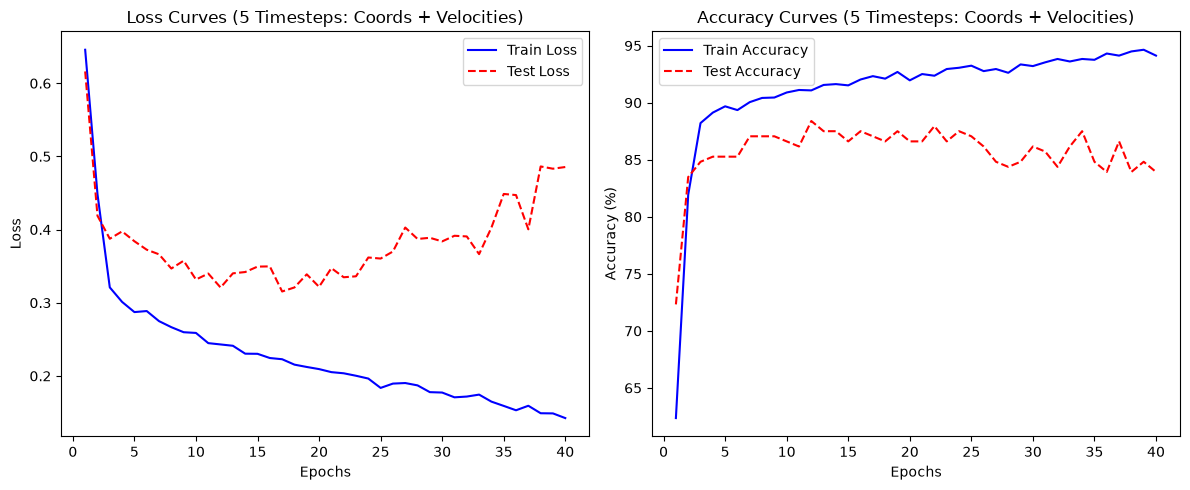

In [63]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss", color="red", linestyle="--")
plt.title("Loss Curves (5 Timesteps: Coords + Velocities)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Accuracy", color="red", linestyle="--")
plt.title("Accuracy Curves (5 Timesteps: Coords + Velocities)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluation: Heatmap & Text Confusion Matrix & Classification Report

In [ ]:
model_5step.eval()
all_preds, all_targets = [], []
with torch.inference_mode():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        logits = model_5step(X_b)
        preds = torch.round(torch.sigmoid(logits)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy())

all_preds = np.array(all_preds).squeeze()
all_targets = np.array(all_targets).squeeze()

cm = confusion_matrix(all_targets, all_preds)
labels = ["Untouch (0)", "Touch (1)"]

# 1. Printed Text Output
print("\n" + "="*50)
print(" CONFUSION MATRIX (FingerTouchLSTM 5-Step)")
print("="*50)
print(cm)
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=labels))
print("="*50)

# 2. Graphical Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Heatmap - FingerTouchLSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 9. Single Sequence Inference Helper Function

In [9]:
def predict_touch(model, seq_5x16):
    model.eval()
    tensor_in = torch.tensor(seq_5x16, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.inference_mode():
        logits = model(tensor_in)
        prob = torch.sigmoid(logits).item()
        
    is_touch = prob >= 0.5
    return prob, is_touch

# Test sample
sample_seq = X_test[0].numpy()
prob, is_touch = predict_touch(model_5step, sample_seq)
print(f"Predicted Touch Probability: {prob:.4f} -> Is Touch: {is_touch}")

## 10. Saving Model Weights

In [10]:
MODEL_SAVE_PATH = "finger_touch_5step_lstm.pth"
torch.save(model_5step.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved successfully to: {MODEL_SAVE_PATH}")